In [2]:
# This notebook will record the results of the simulation and all the KPIs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Hello World")


Hello World


In [7]:
RUNS = {
    '182954': '../sim_results/20260703_182954_simulation_patient_timestamps.csv',
    '182816': '../sim_results/20260703_182816_simulation_patient_timestamps.csv',
}

def load_waiting_times(path):
    df = pd.read_csv(path, skipinitialspace=True)
    df.columns = df.columns.str.strip()

    for col in ['Screening Queue', 'Screening Start', 'Reporting Queue', 'Reporting Start']:
        df[col] = pd.to_datetime(df[col])

    df['waiting_for_screening_days'] = (
        df['Screening Start'] - df['Screening Queue']
    ).dt.total_seconds() / (24 * 3600)

    df['waiting_for_reporting_days'] = (
        df['Reporting Start'] - df['Reporting Queue']
    ).dt.total_seconds() / (24 * 3600)

    return df

dfs = {run_id: load_waiting_times(path) for run_id, path in RUNS.items()}

for run_id, df in dfs.items():
    print(f"\n{run_id} run: {len(df)} patients")
    display(df[['Patient ID', 'waiting_for_screening_days', 'waiting_for_reporting_days']].head())


182954 run: 10005 patients


,Patient ID,waiting_for_screening_days,waiting_for_reporting_days
0,Pap-000001,0.280556,0.697222
1,Pap-000002,0.122222,0.692361
2,Pap-000003,0.091667,0.684028
3,Pap-000004,0.128472,0.000000
4,Pap-000005,0.074306,0.000000



182816 run: 9866 patients


,Patient ID,waiting_for_screening_days,waiting_for_reporting_days
0,Pap-000001,0.280556,0.697222
1,Pap-000002,0.138889,0.679167
2,Pap-000003,0.109028,0.661111
3,Pap-000004,0.136111,0.000000
4,Pap-000005,0.122222,0.000000


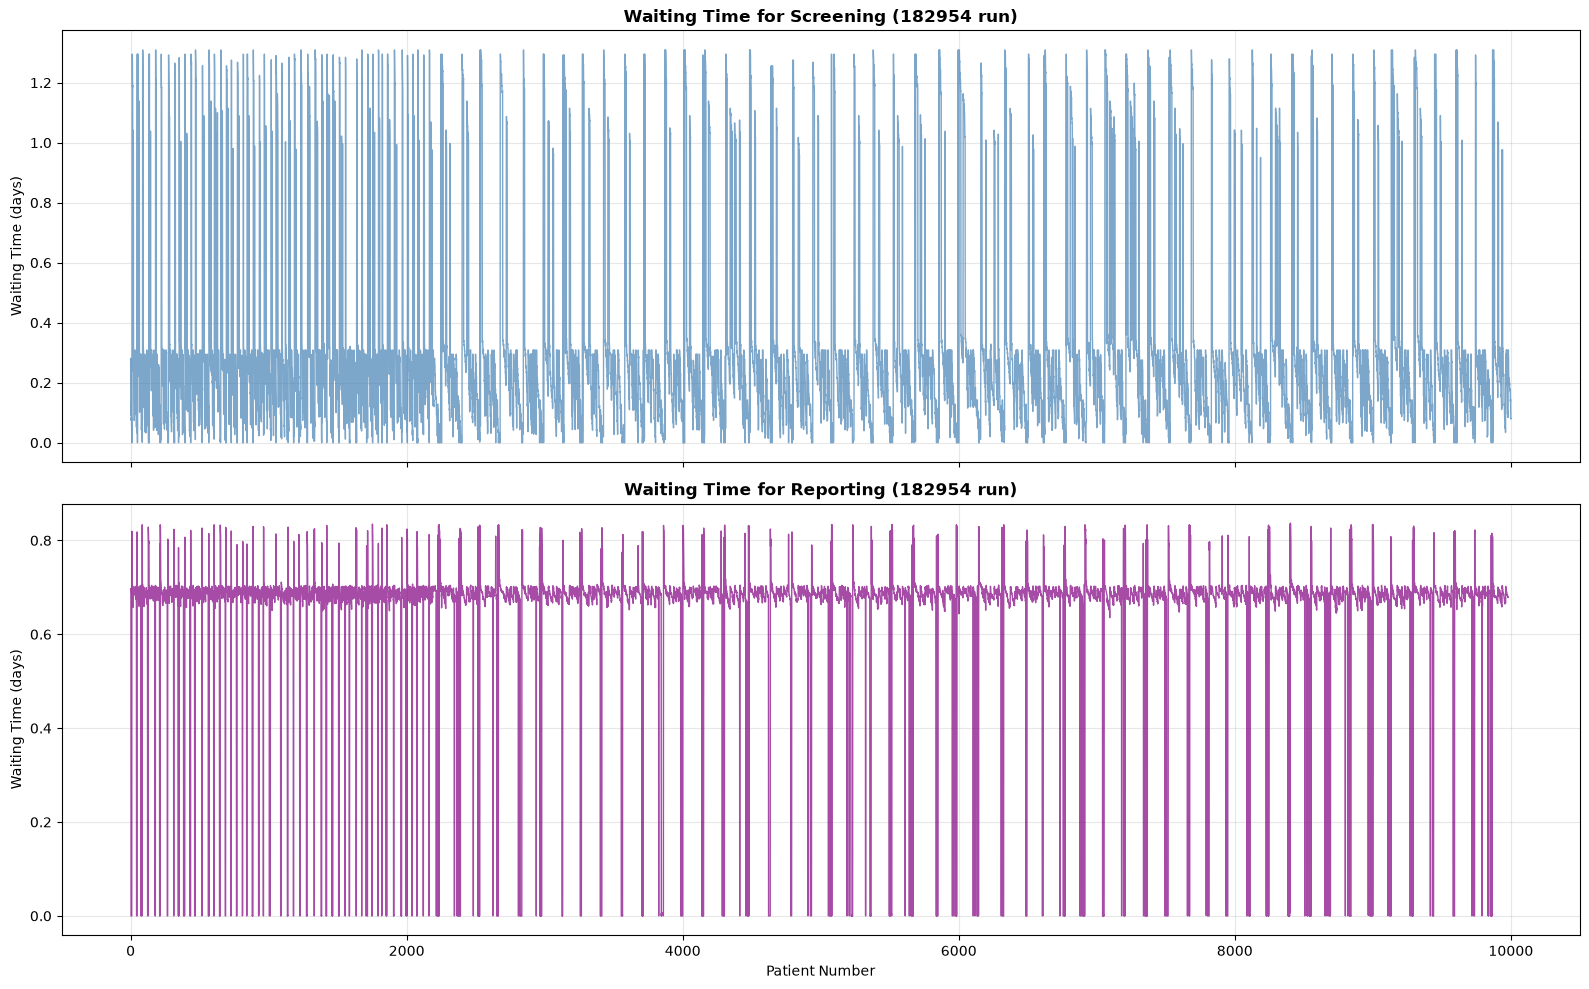


182954 - Waiting Time for Screening Statistics:
  Mean:   0.305 days
  Median: 0.216 days
  Std:    0.342 days
  Min:    0.000 days
  Max:    1.309 days

182954 - Waiting Time for Reporting Statistics:
  Mean:   0.639 days
  Median: 0.686 days
  Std:    0.184 days
  Min:    0.000 days
  Max:    0.837 days


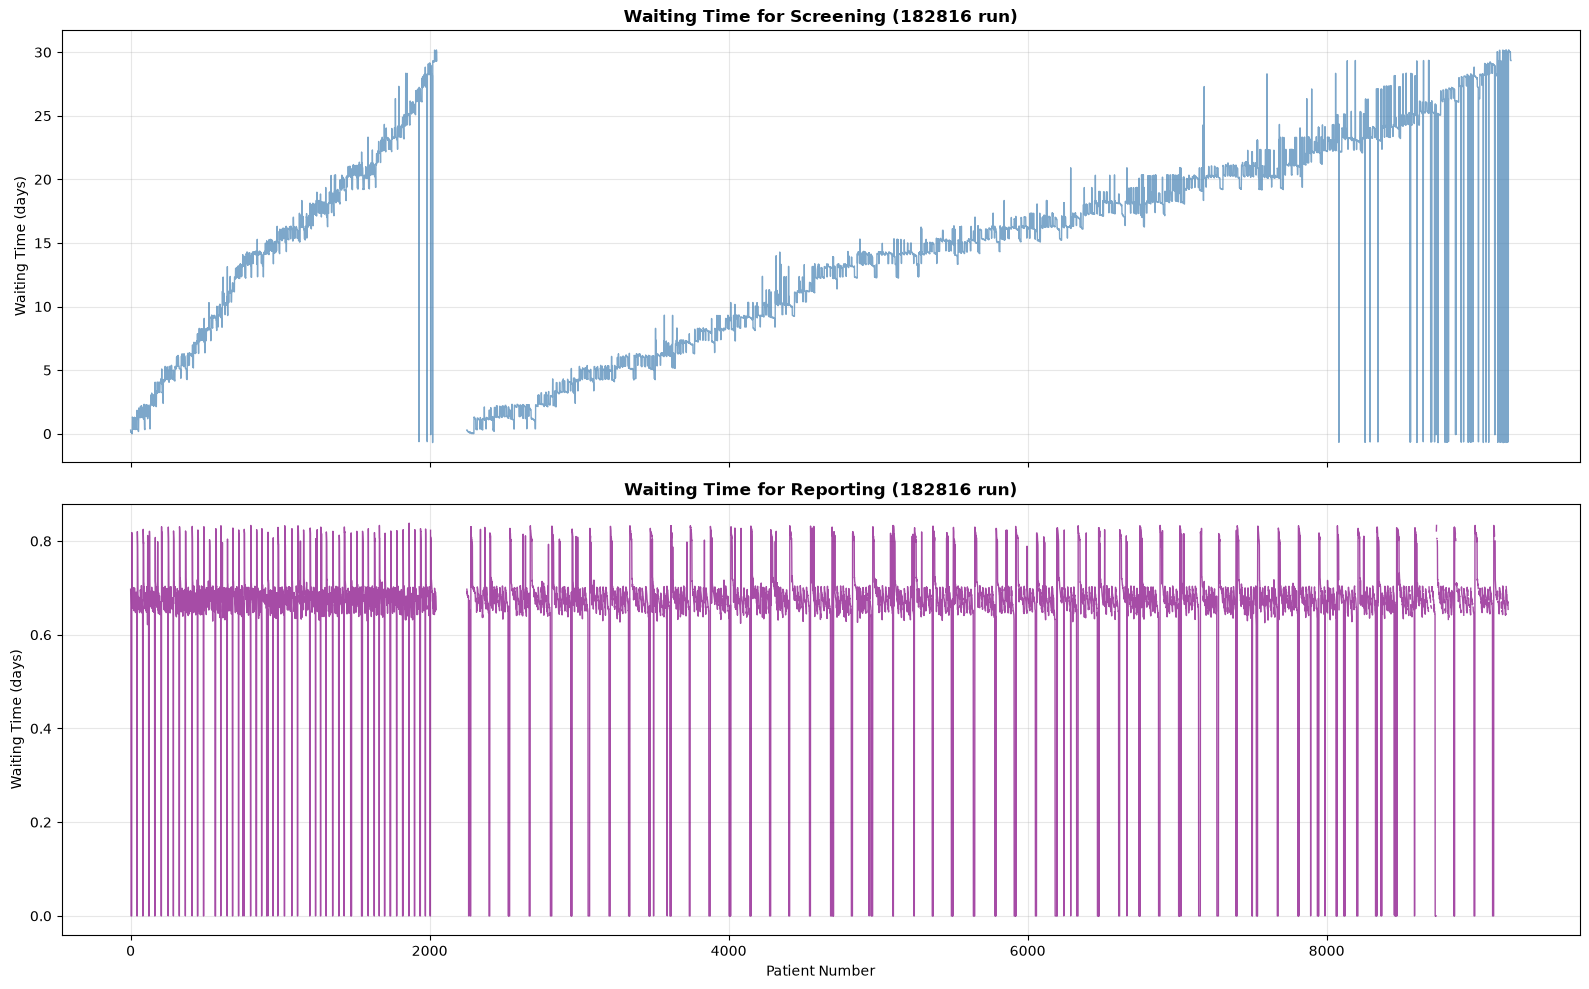


182816 - Waiting Time for Screening Statistics:
  Mean:   14.639 days
  Median: 15.254 days
  Std:    7.715 days
  Min:    -0.706 days
  Max:    30.175 days

182816 - Waiting Time for Reporting Statistics:
  Mean:   0.646 days
  Median: 0.676 days
  Std:    0.170 days
  Min:    0.000 days
  Max:    0.838 days


In [8]:
for run_id, df in dfs.items():
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(df.index, df['waiting_for_screening_days'], linewidth=1, alpha=0.7, color='steelblue')
    axes[0].set_ylabel('Waiting Time (days)')
    axes[0].set_title(f'Waiting Time for Screening ({run_id} run)', fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df.index, df['waiting_for_reporting_days'], linewidth=1, alpha=0.7, color='purple')
    axes[1].set_xlabel('Patient Number')
    axes[1].set_ylabel('Waiting Time (days)')
    axes[1].set_title(f'Waiting Time for Reporting ({run_id} run)', fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    for label, col in [('Screening', 'waiting_for_screening_days'), ('Reporting', 'waiting_for_reporting_days')]:
        print(f"\n{run_id} - Waiting Time for {label} Statistics:")
        print(f"  Mean:   {df[col].mean():.3f} days")
        print(f"  Median: {df[col].median():.3f} days")
        print(f"  Std:    {df[col].std():.3f} days")
        print(f"  Min:    {df[col].min():.3f} days")
        print(f"  Max:    {df[col].max():.3f} days")

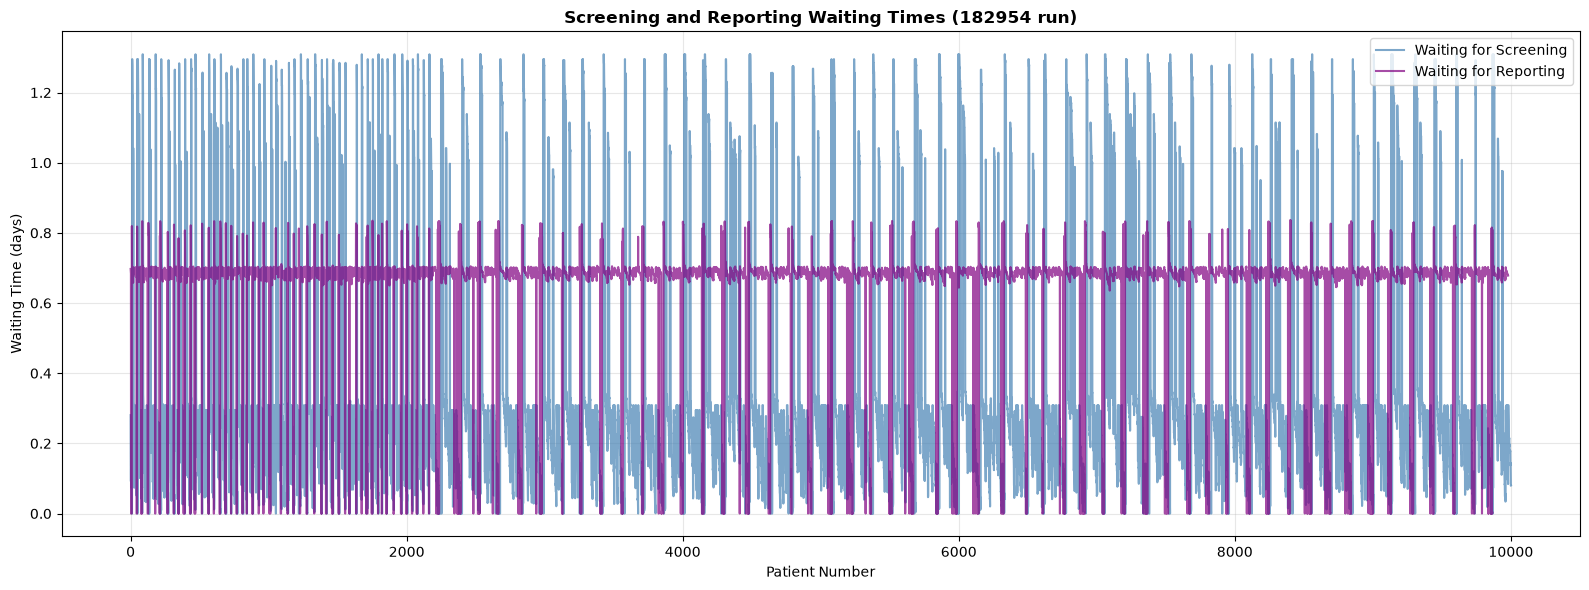

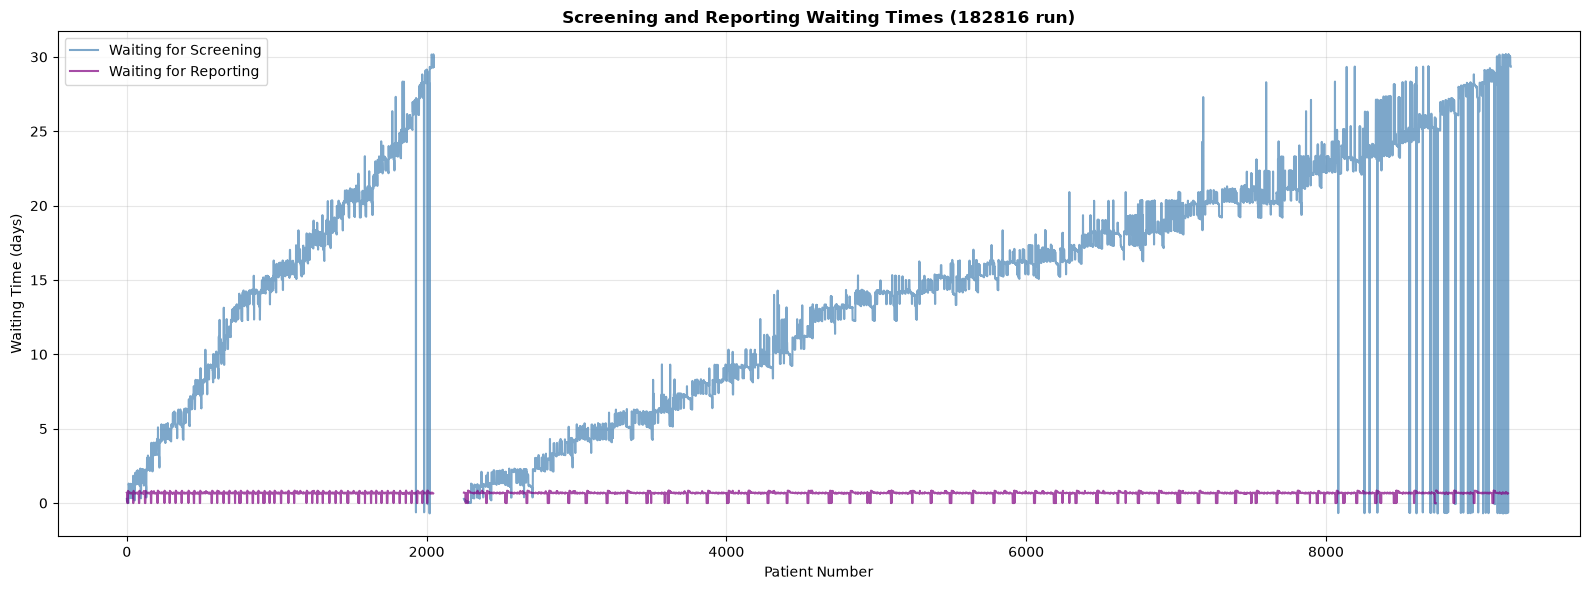

In [9]:
for run_id, df in dfs.items():
    plt.figure(figsize=(16, 6))
    plt.plot(df.index, df['waiting_for_screening_days'], label='Waiting for Screening',
             linewidth=1.5, alpha=0.7, color='steelblue')
    plt.plot(df.index, df['waiting_for_reporting_days'], label='Waiting for Reporting',
             linewidth=1.5, alpha=0.7, color='purple')
    plt.xlabel('Patient Number')
    plt.ylabel('Waiting Time (days)')
    plt.title(f'Screening and Reporting Waiting Times ({run_id} run)', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()